# cosmocnc_jax tutorial

In this tutorial we will illustrate the main computational capabilities of `cosmocnc_jax` using a Simons-Observatory-like cluster catalogue with two mass observables, the tSZ signal-to-noise and the CMB lensing signal-to-noise.

`cosmocnc_jax` is a JAX-accelerated port of [`cosmocnc`](https://github.com/inigozubeldia/cosmocnc), providing GPU/TPU acceleration and automatic differentiation for galaxy cluster number count likelihoods.

## Input parameters

We first set the `cosmocnc_jax` input parameters.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["XLA_FLAGS"] = ""
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
import time

import cosmocnc_jax

print(f"JAX devices: {jax.devices()}")
print(f"Float64 enabled: {jnp.zeros(1).dtype == jnp.float64}")

/scratch/scratch-lxu/venv/cmbagent_env/lib/python3.12/site-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda13_plugin version 0.8.2 is installed, but it is not compatible with the installed jaxlib version 0.10.0, so it will not be used.
  warnings.warn(
W0000 00:00:1777473463.417911 1103778 gpu_device.cc:2431] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


defaulting to  /rds-d4/user/iz221/hpc-work/cosmopower/
defaulting to  /scratch/scratch-lxu/compute_packages/cosmocnc_jax/cosmocnc_jax/
JAX devices: [CudaDevice(id=0)]
Float64 enabled: True


In [2]:
cnc_params = cosmocnc_jax.cnc_params_default
scal_rel_params = cosmocnc_jax.scaling_relation_params_default
cosmo_params = cosmocnc_jax.cosmo_params_default

# Catalogue and observables
cnc_params["cluster_catalogue"] = "SO_sim_0"
cnc_params["observables"] = [["q_so_sim"],["p_so_sim"]]
cnc_params["obs_select"] = "q_so_sim"

# Mass and redshift range
cnc_params["M_min"] = 1e13
cnc_params["M_max"] = 1e16
cnc_params["z_min"] = 0.01
cnc_params["z_max"] = 3.

# Selection observable range
cnc_params["obs_select_min"] = 5.
cnc_params["obs_select_max"] = 200.

# Precision parameters
cnc_params["n_points"] = 16384
cnc_params["n_points_data_lik"] = 2048
cnc_params["n_z"] = 100
cnc_params["sigma_mass_prior"] = 10
cnc_params["delta_m_with_ref"] = True
cnc_params["scalrel_type_deriv"] = "numerical"
cnc_params["downsample_hmf_bc"] = 2
cnc_params["compute_abundance_matrix"] = True

# Parallelisation
cnc_params["number_cores_hmf"] = 1
cnc_params["number_cores_abundance"] = 1
cnc_params["number_cores_data"] = 1
cnc_params["number_cores_stacked"] = 1
cnc_params["parallelise_type"] = "redshift"

# Cosmology parameters
cnc_params["cosmology_tool"] = "classy_sz_jax"
cnc_params["hmf_calc"] = "cnc"
cnc_params["cosmo_param_density"] = "critical"
cnc_params["cosmo_model"] = "lcdm"

# Parameters for the binned likelihood
cnc_params["binned_lik_type"] = "z_and_obs_select"
cnc_params["bins_edges_z"] = np.linspace(cnc_params["z_min"],
                                         cnc_params["z_max"], 9)
cnc_params["bins_edges_obs_select"] = np.exp(np.linspace(
    np.log(cnc_params["obs_select_min"]),
    np.log(cnc_params["obs_select_max"]), 7))

# Stacked data, set to False for now
cnc_params["stacked_likelihood"] = False
cnc_params["stacked_data"] = ["p_so_sim_stacked"]
cnc_params["compute_stacked_cov"] = True

cnc_params["data_lik_from_abundance"] = False
cnc_params["likelihood_type"] = "unbinned"

scal_rel_params["corr_lnq_lnp"] = 0.
scal_rel_params["bias_sz"] = 0.8

## Code initialisation

We now initialise `cosmocnc_jax`.

In [3]:
number_counts = cosmocnc_jax.cluster_number_counts()

number_counts.cnc_params = cnc_params
number_counts.scal_rel_params = scal_rel_params
number_counts.cosmo_params = cosmo_params

number_counts.initialise()

/scratch/scratch-lxu/compute_packages/cosmocnc_jax/cosmocnc_jax/cnc.py:784: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  self.cosmology = cosmology_model(cosmo_params=self.cosmo_params,
/scratch/scratch-lxu/venv/cmbagent_env/lib/python3.12/site-packages/mcfit/mcfit.py:130: UserWarning: use backend='jax' if desired
  warnings.warn("use backend='jax' if desired")


cosmo params {'Om0': 0.315, 'Ob0': 0.04897, 'Ob0h2': 0.022245895720000002, 'Oc0h2': 0.12085104428000001, 'h': 0.674, 'A_s': np.float64(2.0846720158043235e-09), 'n_s': 0.96, 'm_nu': 0.06, 'sigma_8': 0.8110000000000002, 'tau_reio': 0.0544, 'w0': -1.0, 'Onu0': 0.001418083698824921, 'N_eff': 3.046, 'k_cutoff': 100000000.0, 'ps_cutoff': 1}


## Cluster abundance

Let us now compute and plot the cluster abundance across the selection observable (SZ signal-to-noise, or SNR) and redshift.

In [4]:
number_counts.get_number_counts()

dn_dz = np.asarray(number_counts.n_z)
dn_dSNR = np.asarray(number_counts.n_obs)

z = np.asarray(number_counts.redshift_vec)
SNR = np.asarray(number_counts.obs_select_vec)

As simple as that! We can now plot the one-dimensional abundance across signal-to-noise and redshift.

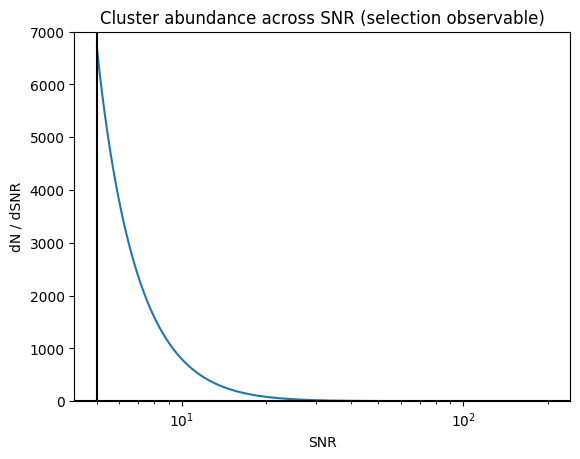

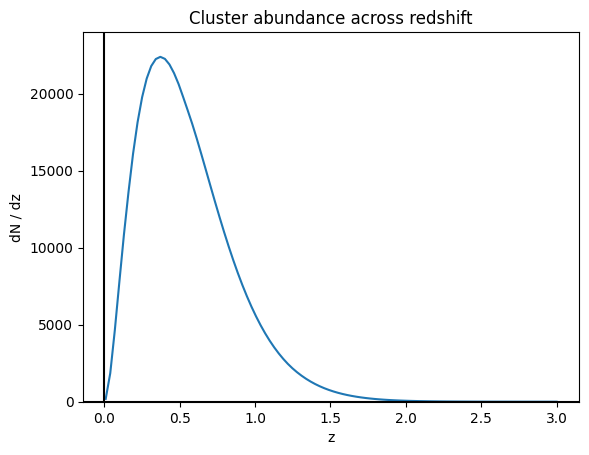

In [5]:
plt.semilogx(SNR, dn_dSNR, color="tab:blue")
plt.xlabel("SNR")
plt.ylabel("dN / dSNR")
plt.axvline(x=5., color="k")
plt.axhline(y=0., color="k")
plt.title("Cluster abundance across SNR (selection observable)")
plt.ylim([0, 7000])
plt.show()

plt.plot(z, dn_dz, color="tab:blue")
plt.xlabel("z")
plt.ylabel("dN / dz")
plt.axvline(x=0., color="k")
plt.axhline(y=0., color="k")
plt.ylim(0, 24000)
plt.title("Cluster abundance across redshift")
plt.show()

We can also retrieve and plot the two-dimensional abundance across both signal-to-noise and redshift.

In [6]:
abundance_matrix = np.flip(np.asarray(number_counts.abundance_matrix), axis=0)

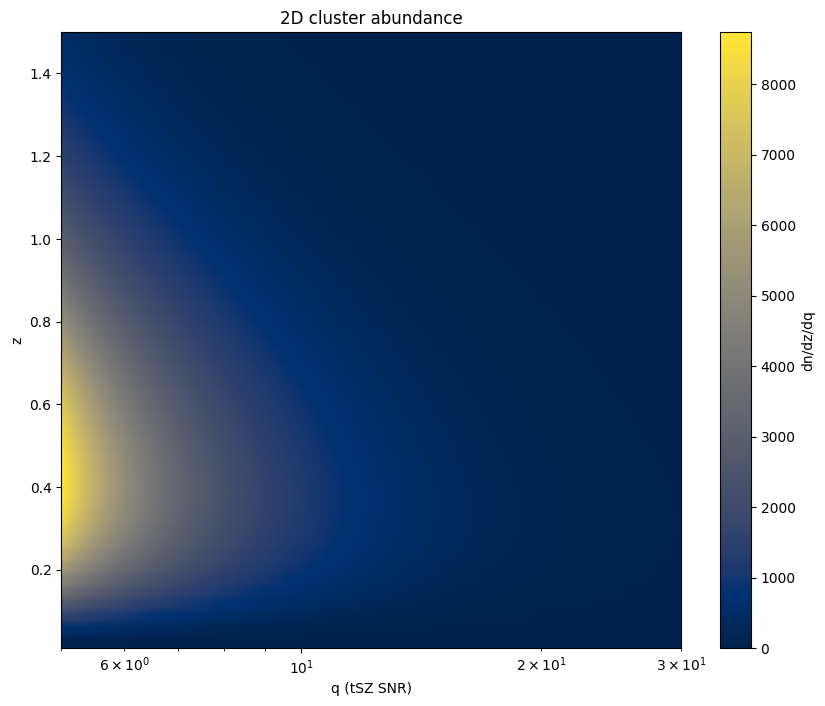

In [7]:
plt.figure(figsize=(10, 8))
ax = plt.gca()
im = ax.imshow(abundance_matrix, aspect='auto', cmap='cividis',
               extent=[SNR[0], SNR[-1], z[0], z[-1]])
plt.colorbar(im, ax=ax, label='dn/dz/dq')
ax.set_xscale('log')
ax.set_xlabel('q (tSZ SNR)')
ax.set_ylabel('z')
ax.set_xlim([5., 30.])
ax.set_ylim([0.01, 1.5])
ax.set_title('2D cluster abundance')
plt.show()

Let us also have a look at the cluster catalogue data.

Number of clusters: 15798
Redshift range: [0.0129, 2.3676]
q (tSZ SNR) range: [5.00, 94.86]
p (lensing SNR) range: [-4.12, 4.08]


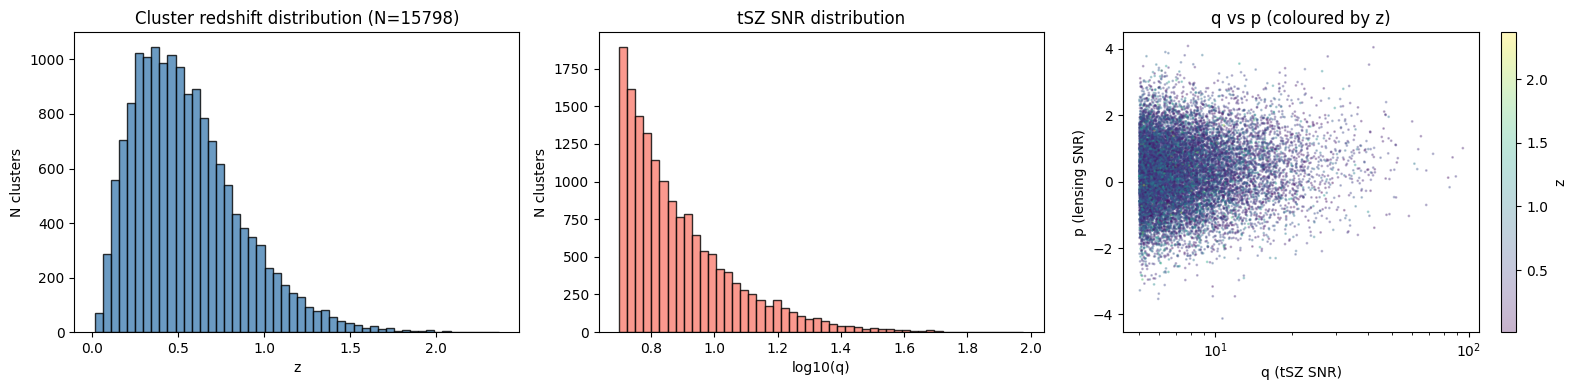

In [8]:
z_obs = np.asarray(number_counts.catalogue.catalogue["z"])
q_obs = np.asarray(number_counts.catalogue.catalogue["q_so_sim"])
p_obs = np.asarray(number_counts.catalogue.catalogue["p_so_sim"])

n_clusters = len(z_obs)
print(f"Number of clusters: {n_clusters}")
print(f"Redshift range: [{z_obs.min():.4f}, {z_obs.max():.4f}]")
print(f"q (tSZ SNR) range: [{q_obs.min():.2f}, {q_obs.max():.2f}]")
print(f"p (lensing SNR) range: [{p_obs.min():.2f}, {p_obs.max():.2f}]")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.hist(z_obs, bins=50, alpha=0.8, color='steelblue', edgecolor='k')
ax.set_xlabel('z')
ax.set_ylabel('N clusters')
ax.set_title(f'Cluster redshift distribution (N={n_clusters})')

ax = axes[1]
ax.hist(np.log10(q_obs), bins=50, alpha=0.8, color='salmon', edgecolor='k')
ax.set_xlabel('log10(q)')
ax.set_ylabel('N clusters')
ax.set_title('tSZ SNR distribution')

ax = axes[2]
sc = ax.scatter(q_obs, p_obs, s=1, alpha=0.3, c=z_obs, cmap='viridis')
ax.set_xlabel('q (tSZ SNR)')
ax.set_ylabel('p (lensing SNR)')
ax.set_xscale('log')
plt.colorbar(sc, ax=ax, label='z')
ax.set_title('q vs p (coloured by z)')

plt.tight_layout()
plt.show()

## Binned cluster abundance

Let us now integrate the cluster abundance within SNR and redshift bins to obtain the binned abundance, and compare it with the cluster catalogue. For this we need to call the binned likelihood. Note that the bin edges were already defined when we set the parameters.

In [9]:
cnc_params["likelihood_type"] = "binned"
cnc_params["obs_select_min"] = 5.000

number_counts.cnc_params = cnc_params

log_lik = number_counts.get_log_lik()  # Evaluate the binned likelihood

bins_centres_z = number_counts.bins_centres_z  # z bins centres
bins_centres_snr = number_counts.bins_centres_obs  # SNR bins centres

n_binned_theory = np.asarray(number_counts.n_binned)  # Theoretical prediction
n_binned_obs = np.asarray(number_counts.n_binned_obs)  # Actual number counts

n_tot_bins_theory = np.sum(n_binned_theory)
n_tot_bins_obs = np.sum(n_binned_obs)

n_binned_snr_theory = np.sum(n_binned_theory, axis=0)
n_binned_snr_obs = np.sum(n_binned_obs, axis=0)

n_binned_z_theory = np.sum(n_binned_theory, axis=1)
n_binned_z_obs = np.sum(n_binned_obs, axis=1)

print(f"Predicted total number of clusters in the bins = {n_tot_bins_theory:.1f} +/- {np.sqrt(n_tot_bins_theory):.1f}")
print(f"Observed total number of clusters in the bins = {n_tot_bins_obs:.0f}")

Predicted total number of clusters in the bins = 15625.4 +/- 125.0
Observed total number of clusters in the bins = 15798


This is, incidentally, how the log-likelihood is called. Note that the predicted total number of clusters in the bins is slightly smaller than the prediction for the full catalogue, as our bins, as defined in the parameters, do not cover the full observable range.

Let's now plot the binned abundances.

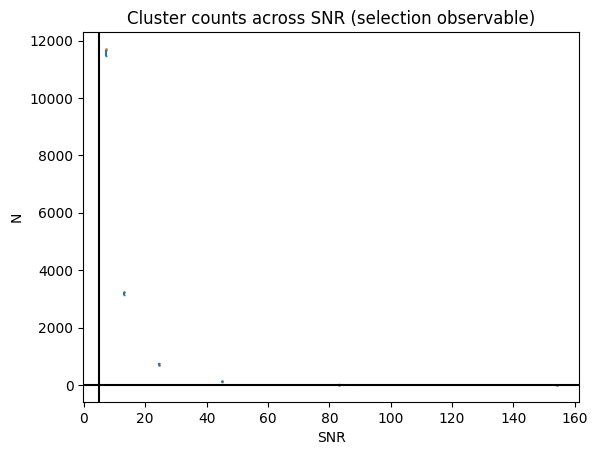

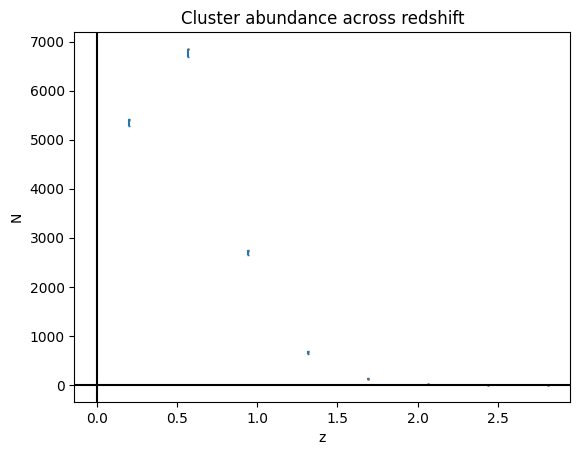

In [10]:
size_marker = 1

plt.errorbar(bins_centres_snr, n_binned_snr_theory, yerr=np.sqrt(n_binned_snr_theory),
             color="tab:blue", linestyle="none", fmt="", capsize=size_marker)
plt.scatter(bins_centres_snr, n_binned_snr_obs, color="tab:orange", s=size_marker)
plt.xlabel("SNR")
plt.ylabel("N")
plt.axvline(x=5., color="k")
plt.axhline(y=0., color="k")
plt.title("Cluster counts across SNR (selection observable)")
plt.show()

plt.errorbar(bins_centres_z, n_binned_z_theory, yerr=np.sqrt(n_binned_z_theory),
             color="tab:blue", linestyle="none", fmt="", capsize=size_marker)
plt.scatter(bins_centres_z, n_binned_z_obs, color="tab:orange", s=size_marker)
plt.xlabel("z")
plt.ylabel("N")
plt.axvline(x=0., color="k")
plt.axhline(y=0., color="k")
plt.title("Cluster abundance across redshift")
plt.show()

Alternatively, if you are only interested in the binned number counts across either the selection observable or redshift, they can be computed directly by setting `binned_lik_type` to either `obs_select` or `z`.

## Stacked observable

`cosmocnc_jax` can compute the expected value of any of the stacked observables and its (co)variance. In our SO-like catalogue, this is the stacked CMB lensing signal-to-noise. This can be done as follows:

In [11]:
cnc_params["likelihood_type"] = "unbinned"
cnc_params["observables"] = [["q_so_sim"]]  # One cluster-by-cluster mass observable
cnc_params["data_lik_from_abundance"] = False  # Backward convolutional approach (necessary for stacked)
cnc_params["stacked_likelihood"] = True
cnc_params["stacked_data"] = ["p_so_sim_stacked"]  # List of stacked data
cnc_params["compute_stacked_cov"] = True

number_counts.cnc_params = cnc_params

number_counts.initialise()
log_lik = number_counts.get_log_lik()  # Compute the unbinned + stacked likelihood

cosmo params {'Om0': 0.315, 'Ob0': 0.04897, 'Ob0h2': 0.022245895720000002, 'Oc0h2': 0.12085104428000001, 'h': 0.674, 'A_s': np.float64(2.0846720158043235e-09), 'n_s': 0.96, 'm_nu': 0.06, 'sigma_8': 0.8110000000000002, 'tau_reio': 0.0544, 'w0': -1.0, 'Onu0': 0.001418083698824921, 'N_eff': 3.046, 'k_cutoff': 100000000.0, 'ps_cutoff': 1}


We now retrieve the results:

In [12]:
p_stacked_obs = np.asarray(number_counts.catalogue.stacked_data["p_so_sim_stacked"]["data_vec"])
p_stacked_theory = np.asarray(number_counts.stacked_model["p_so_sim_stacked"])
p_stacked_std = np.sqrt(np.asarray(number_counts.stacked_variance["p_so_sim_stacked"]))

print(f"Predicted stacked observable = {float(p_stacked_theory.ravel()[0]):.6f} +/- {float(p_stacked_std.ravel()[0]):.6f}")
print(f"Observed stacked observable = {float(p_stacked_obs.ravel()[0]):.6f}")

Predicted stacked observable = 0.040226 +/- 0.007956
Observed stacked observable = 0.298620


Note that, in this case, we can also easily compute the observed value of the stacked observable from the catalogue itself:

In [13]:
p_stacked_obs_2 = np.mean(p_obs)
print(f"Observed stacked observable = {p_stacked_obs_2:.6f}")

Observed stacked observable = 0.298620


## Likelihood evaluation

Let us now evaluate and plot the unbinned likelihood for the SZ signal-to-noise as a function of $\sigma_8$.

In [14]:
cnc_params["likelihood_type"] = "unbinned"
cnc_params["observables"] = [["q_so_sim"]]  # One cluster-by-cluster mass observable
cnc_params["data_lik_from_abundance"] = True  # Forward convolutional approach (faster)
cnc_params["stacked_likelihood"] = False

number_counts.cnc_params = cnc_params
number_counts.initialise()

n = 20
sigma_8_vec = np.linspace(0.808, 0.815, n)
log_lik_scan = np.zeros(n)

t0 = time.time()
for i in range(n):
    cosmo_params["sigma_8"] = sigma_8_vec[i]
    number_counts.update_params(cosmo_params, scal_rel_params)
    ll = number_counts.get_log_lik()
    jax.block_until_ready(ll)
    log_lik_scan[i] = float(np.asarray(ll))
t_scan = time.time() - t0

lik_vec = np.exp(log_lik_scan - np.max(log_lik_scan))

cosmo_params["sigma_8"] = 0.811

print(f"Scan completed in {t_scan:.1f}s ({t_scan/n*1000:.0f} ms/eval)")

cosmo params {'Om0': 0.315, 'Ob0': 0.04897, 'Ob0h2': 0.022245895720000002, 'Oc0h2': 0.12085104428000001, 'h': 0.674, 'A_s': np.float64(2.0846720158043235e-09), 'n_s': 0.96, 'm_nu': 0.06, 'sigma_8': 0.8110000000000002, 'tau_reio': 0.0544, 'w0': -1.0, 'Onu0': 0.001418083698824921, 'N_eff': 3.046, 'k_cutoff': 100000000.0, 'ps_cutoff': 1}
Scan completed in 3.4s (172 ms/eval)


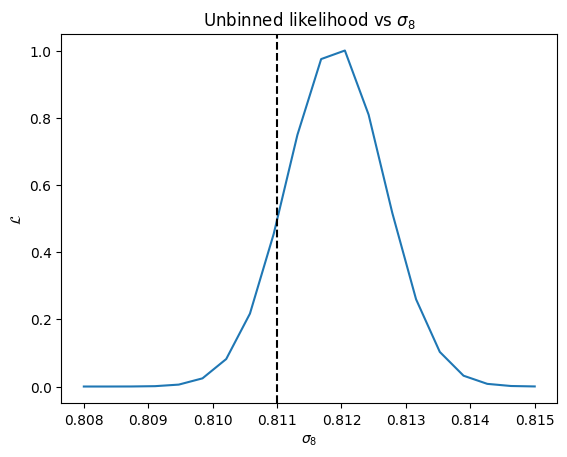

In [15]:
plt.plot(sigma_8_vec, lik_vec)
plt.axvline(x=0.811, linestyle="dashed", color="k")
plt.xlabel(r"$\sigma_8$")
plt.ylabel(r"$\mathcal{L}$")
plt.title(r"Unbinned likelihood vs $\sigma_8$")
plt.show()

Here, the dashed vertical line is the true value of $\sigma_8$ for our synthetic catalogue.

The same exercise can be done for the other likelihoods with minor modifications to the code. In particular:

- Binned likelihood: set `likelihood_type` to `binned`, and choose binning scheme through `binned_lik_type`.
- Unbinned likelihood with both the SZ and the CMB lensing mass observable: set `observables` to `[["q_so_sim"],["p_so_sim"]]` (if they belong to different correlation sets, which is the case here), or to `[["q_so_sim","p_so_sim"]]` (if they belong to the same correlation set).
- Unbinned likelihood with the CMB lensing stacked observable: set `stacked_likelihood` to `True` and `data_lik_from_abundance` to `False`.
- Extreme value likelihood: set `likelihood_type` to `extreme_value`.

## Goodness of fit

We can easily evaluate the modified Cash goodness-of-fit statistic and compare its value with the theoretical prediction. Here we do so at the true model parameters:

In [16]:
number_counts.cnc_params = cnc_params
number_counts.initialise()

C, C_mean, C_std = number_counts.get_c_statistic()

print(f"Predicted C = {float(np.asarray(C_mean)):.2f} +/- {float(np.asarray(C_std)):.2f}")
print(f"Observed C = {float(np.asarray(C)):.2f}")

cosmo params {'Om0': 0.315, 'Ob0': 0.04897, 'Ob0h2': 0.022245895720000002, 'Oc0h2': 0.12085104428000001, 'h': 0.674, 'A_s': np.float64(2.0846720158043235e-09), 'n_s': 0.96, 'm_nu': 0.06, 'sigma_8': 0.8110000000000002, 'tau_reio': 0.0544, 'w0': -1.0, 'Onu0': 0.001418083698824921, 'N_eff': 3.046, 'k_cutoff': 100000000.0, 'ps_cutoff': 1}
Predicted C = 24.63 +/- 6.88
Observed C = 10.46


## Cluster mass estimation

Let us now estimate the masses of the clusters in the catalogue. For this we will only use the SZ mass observable (as well as the redshifts).

In [17]:
cnc_params["likelihood_type"] = "unbinned"
cnc_params["observables"] = [["q_so_sim"]]
cnc_params["data_lik_from_abundance"] = False  # Backward convolutional approach (needed)
cnc_params["get_masses"] = True

number_counts.cnc_params = cnc_params

number_counts.initialise()
number_counts.get_log_lik()
number_counts.get_masses()

cosmo params {'Om0': 0.315, 'Ob0': 0.04897, 'Ob0h2': 0.022245895720000002, 'Oc0h2': 0.12085104428000001, 'h': 0.674, 'A_s': np.float64(2.0846720158043235e-09), 'n_s': 0.96, 'm_nu': 0.06, 'sigma_8': 0.8110000000000002, 'tau_reio': 0.0544, 'w0': -1.0, 'Onu0': 0.001418083698824921, 'N_eff': 3.046, 'k_cutoff': 100000000.0, 'ps_cutoff': 1}


In [18]:
ln_mass_est = np.asarray(number_counts.cluster_lnM)  # ln mass estimates
ln_mass_std = np.asarray(number_counts.cluster_lnM_std)  # ln mass standard deviation

Since we are using a synthetic catalogue, we also have access to the true cluster mass.

In [19]:
mass_true = np.asarray(number_counts.catalogue.M)  # true mass [1e14 M_sun]

We can now plot the estimated masses against the true masses.

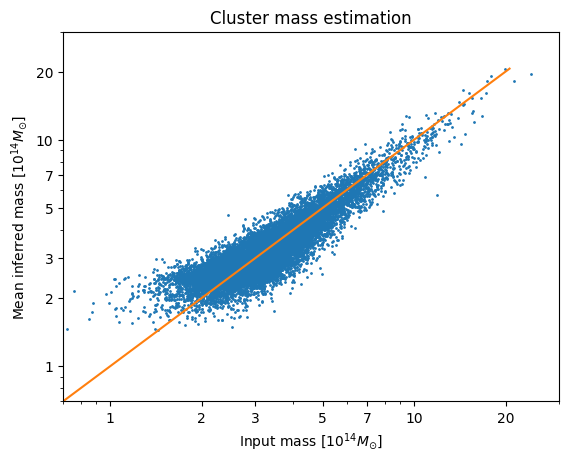

In [20]:
m_x = mass_true
m_y = np.exp(ln_mass_est)

fig = plt.figure()
gs = fig.add_gridspec(1, 1)
axs = gs.subplots()

axs.scatter(m_x, m_y, s=1)
x = np.linspace(np.min(m_x), np.max(m_y), 100)
axs.plot(x, x, color="tab:orange")
axs.set_xscale("log")
axs.set_yscale("log")
axs.set_xlim([0.7, 30.])
axs.set_ylim([0.7, 30.])

custom_ticks = [1, 2, 3, 5, 7, 10, 20]

axs.set_xticks(custom_ticks)
axs.set_yticks(custom_ticks)
axs.set_xticklabels(custom_ticks)
axs.set_yticklabels(custom_ticks)
axs.set_ylabel(r"Mean inferred mass [$10^{14} M_{\odot}$]")
axs.set_xlabel(r"Input mass [$10^{14} M_{\odot}$]")

axs.set_title("Cluster mass estimation")

plt.show()

## Most extreme cluster

Finally, let's consider the "most extreme cluster", which we define as that with the largest value of the selection observable (SZ signal-to-noise in the SO-like catalogue).

In [21]:
number_counts.initialise()
number_counts.get_log_lik_extreme_value()
number_counts.eval_extreme_value_quantities()

snr_max_mean = float(np.asarray(number_counts.obs_select_max_mean))
snr_max_std = float(np.asarray(number_counts.obs_select_max_std))
snr_max_obs = float(np.max(q_obs))

print(f"Predicted maximum SNR = {snr_max_mean:.2f} +/- {snr_max_std:.2f}")
print(f"Observed maximum SNR = {snr_max_obs:.2f}")

/scratch/scratch-lxu/compute_packages/cosmocnc_jax/cosmocnc_jax/cnc.py:784: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  self.cosmology = cosmology_model(cosmo_params=self.cosmo_params,
/scratch/scratch-lxu/venv/cmbagent_env/lib/python3.12/site-packages/mcfit/mcfit.py:130: UserWarning: use backend='jax' if desired
  warnings.warn("use backend='jax' if desired")


cosmo params {'Om0': 0.315, 'Ob0': 0.04897, 'Ob0h2': 0.022245895720000002, 'Oc0h2': 0.12085104428000001, 'h': 0.674, 'A_s': np.float64(2.0846720158043235e-09), 'n_s': 0.96, 'm_nu': 0.06, 'sigma_8': 0.8110000000000002, 'tau_reio': 0.0544, 'w0': -1.0, 'Onu0': 0.001418083698824921, 'N_eff': 3.046, 'k_cutoff': 100000000.0, 'ps_cutoff': 1}
Predicted maximum SNR = 115.58 +/- 24.60
Observed maximum SNR = 94.86
